In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis

from pytorch_ood.detector import KNN, Mahalanobis, GMM
from pytorch_ood.utils import OODMetrics

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


from scipy.stats import gaussian_kde


In [2]:
def compute_tsne_id_ood(
    Z_id,
    Y_id,
    Z_ood,
    y_ood=None,
    use_pca=False,
    n_pca_max=50,
    perplexity=30,
    random_state=42,
):
    # Convert tensors to numpy
    X_id = Z_id.detach().cpu().numpy()
    y_id = Y_id.detach().cpu().numpy()

    X_ood = Z_ood.detach().cpu().numpy()

    if y_ood is not None:
        y_ood = y_ood.detach().cpu().numpy()
    else:
        y_ood = np.full(shape=(X_ood.shape[0],), fill_value=-1)

    # Concatenate ID and OOD
    X_all = np.concatenate([X_id, X_ood], axis=0)
    y_all = np.concatenate([y_id, y_ood], axis=0)

    domain_all = np.concatenate([
        np.zeros(X_id.shape[0], dtype=int),  # 0 = ID
        np.ones(X_ood.shape[0], dtype=int),  # 1 = OOD
    ])

    # Optional PCA
    if use_pca:
        n_pca = min(n_pca_max, X_all.shape[1], X_all.shape[0])
        X_tsne_input = PCA(
            n_components=n_pca,
            random_state=random_state
        ).fit_transform(X_all)
    else:
        X_tsne_input = X_all

    # t-SNE
    X_tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(X_tsne_input)

    # Split back
    X_tsne_id = X_tsne[domain_all == 0]
    X_tsne_ood = X_tsne[domain_all == 1]

    y_id_plot = y_all[domain_all == 0]
    y_ood_plot = y_all[domain_all == 1]

    return X_tsne_id, X_tsne_ood, y_id_plot, y_ood_plot




def plot_kde(id_scores, ood_scores, title):
    fig, ax = plt.subplots(figsize=(6, 4))

    x = np.linspace(
        min(id_scores.min(), ood_scores.min()),
        max(id_scores.max(), ood_scores.max()),
        1000,
    )

    ax.plot(x, gaussian_kde(id_scores)(x), label="ID")
    ax.plot(x, gaussian_kde(ood_scores)(x), label="OOD")
    ax.set_title(title)
    ax.legend()

    return fig



In [12]:
z1=torch.load("nnUNet_INbreast_allmasses")
z2=torch.load("VersaMammo_INbreast_nomasses")

print(z1.shape, z2.shape)


torch.Size([108, 512]) torch.Size([237, 768])


In [13]:
ZGT_dict = {
    "MedSAM":{
        "masses":["MedSAM_zs_ZGT_nomasses",
                       "MedSAM_zs_ZGT_masses"],
        "mal_ben":["MedSAM_zs_ZGT_benign",
                    "MedSAM_zs_ZGT_malignant"],
    },
    "VersaMammo": {
        "masses": ["VersaMammo_ZGT_nomasses",
            "VersaMammo_ZGT_allmasses"
        ],
        "mal_ben": ["VersaMammo_ZGT_benign",
            "VersaMammo_ZGT_malignant"
        ]
    },
    "MammoFM": {
        "masses": ["MammoFM_ZGT_nomasses",
            "MammoFM_ZGT_allmasses"
        ],
        "mal_ben": ["MammoFM_ZGT_benign",
            "MammoFM_ZGT_malignant"
        ]
    },
    
        "nnUNet": {
        "masses": ["nnUNet_ZGT_nomasses",
            "nnUNet_ZGT_allmasses"
        ],
        "mal_ben": ["nnUNet_ZGT_benign",
            "nnUNet_ZGT_malignant"
        ]
    }
}


INbreast_dict={"MedSAM":["medSAM_zs_INbreast_nomasses","medSAM_zs_INbreast_masses"],
              "VersaMammo":["VersaMammo_INbreast_nomasses","VersaMammo_INbreast_allmasses"],
              "MammoFM":["MammoFM_INbreast_nomasses", "MammoFM_INbreast_allmasses"],
               "nnUNet":["nnUNet_INbreast_nomasses", "nnUNet_INbreast_allmasses"]
               
              }

Mama_mia_dict={"MedSAM":["medSAM_LoRA_MamaMia_masses"] ,"VersaMammo":["VersaMammo_MamaMia_masses"], 
               "MammoFM":["MammoFM_MamaMia_masses"], "nnUNet":["nnUNet_MamaMia_allmasses"] }

shift_names = [
    "semantic_shift_healthy_mass",
    "semantic_shift_ben_mal",
    "healthy_covariate_shift",
    "masses_covariate_shift",
    "covariate_semantic_shift_1",
    "covariate_semantic_shift_2",
    "modality_shift"
]

### t-SNE maps

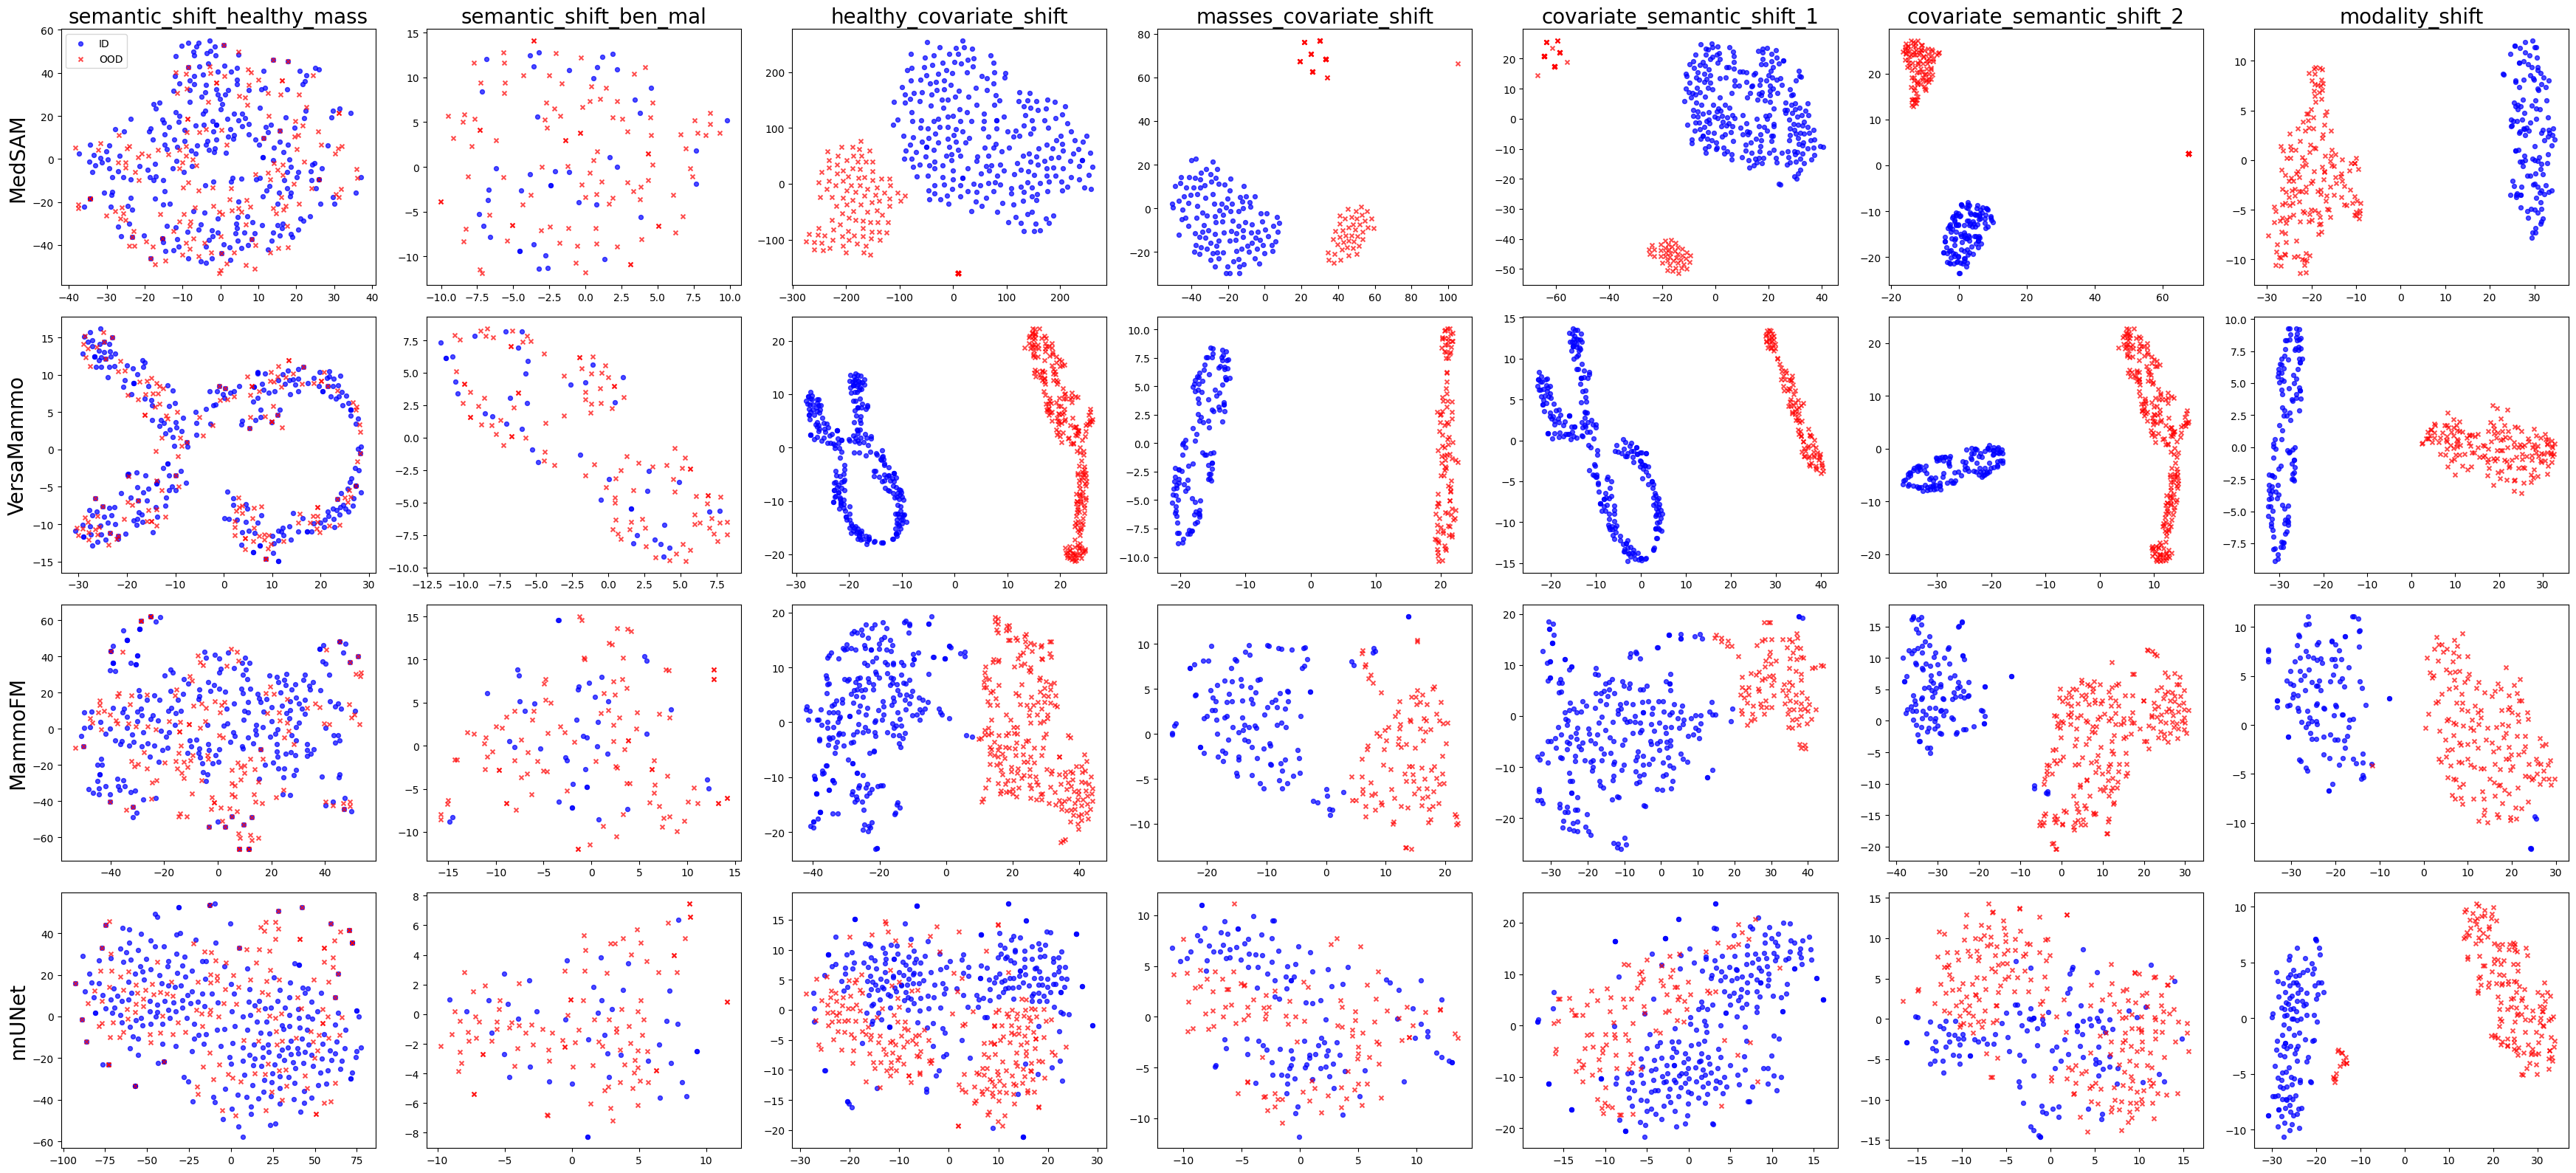

In [14]:
import matplotlib.pyplot as plt
import torch



models = list(ZGT_dict.keys())

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(shift_names),
    figsize=(5 * len(shift_names), 4 * len(models)),
    squeeze=False
)

for row_idx, model in enumerate(models):
    zgt_masses = ZGT_dict[model]["masses"]
    zgt_mal_ben = ZGT_dict[model]["mal_ben"]
    inbreast_values = INbreast_dict[model]
    mamamia_values = Mama_mia_dict[model]

    combinations = {
        "semantic_shift_healthy_mass": zgt_masses,
        "semantic_shift_ben_mal": zgt_mal_ben, 
        "healthy_covariate_shift": [zgt_masses[0], inbreast_values[0]],
        "masses_covariate_shift": [zgt_masses[1], inbreast_values[1]],
        "covariate_semantic_shift_1": [zgt_masses[0], inbreast_values[1]],
        "covariate_semantic_shift_2": [zgt_masses[1], inbreast_values[0]],
        "modality_shift": [zgt_masses[1], mamamia_values[0]]
    }

    for col_idx, shift_name in enumerate(shift_names):
        v = combinations[shift_name]
        ax = axes[row_idx, col_idx]

        Z_id = torch.load(v[0])

        N_fit = int(Z_id.shape[0] * 0.8)
        Z_id_test = Z_id[N_fit:, :]
        Z_id = Z_id[:N_fit, :]

        Z_ood = torch.load(v[1])

        Y_id = torch.zeros(Z_id.shape[0])
        y_ood = -torch.ones(Z_ood.shape[0])

        X_tsne_id, X_tsne_ood, y_id_plot, y_ood_plot = compute_tsne_id_ood(
            Z_id,
            Y_id,
            Z_ood,
            y_ood=y_ood,
            use_pca=True,
        )

        ax.scatter(
            X_tsne_id[:, 0],
            X_tsne_id[:, 1],
            color="blue",
            alpha=0.7,
            s=18,
            label="ID"
        )

        ax.scatter(
            X_tsne_ood[:, 0],
            X_tsne_ood[:, 1],
            color="red",
            alpha=0.7,
            s=18,
            marker="x",
            label="OOD"
        )

        if row_idx == 0:
            ax.set_title(shift_name, fontsize=20)

        if col_idx == 0:
            ax.set_ylabel(model, fontsize=20)

        if row_idx == 0 and col_idx == 0:
            ax.legend()

plt.tight_layout()
plt.savefig("tsne_grid_models_by_shift.png", dpi=300, bbox_inches="tight")
plt.show()

### Test and evaluate different OOD techniques

In [16]:
from torchmetrics.functional.classification import binary_auroc, binary_roc

def auroc_torchmetrics_from_distances(id_scores, ood_scores, higher_is_ood=True):
    scores = torch.tensor(
        list(id_scores) + list(ood_scores),
        dtype=torch.float64,
    )
    target = torch.tensor(
        [0] * len(id_scores) + [1] * len(ood_scores),
        dtype=torch.long,
    )

    if not higher_is_ood:
        scores = -scores

    # prevent TorchMetrics from interpreting distances as logits
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    return binary_auroc(scores, target).item()


def fpr_at_95_tpr_from_distances(id_scores, ood_scores, higher_is_ood=True):
    scores = torch.tensor(
        list(id_scores) + list(ood_scores),
        dtype=torch.float64,
    )
    target = torch.tensor(
        [0] * len(id_scores) + [1] * len(ood_scores),
        dtype=torch.long,
    )

    if not higher_is_ood:
        scores = -scores

    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    fpr, tpr, _ = binary_roc(scores, target)

    return float(np.interp(
        0.95,
        tpr.numpy(),
        fpr.numpy(),
    ))

In [17]:
models = list(ZGT_dict.keys())

detector_classes = {
    "Mahalanobis": Mahalanobis,
    "KNN": KNN,
    "GMM": GMM,
}

results = {}

for detector_name, DetectorCls in detector_classes.items():
    results[detector_name] = {}

    for model in models:
        results[detector_name][model] = {}

        zgt_masses = ZGT_dict[model]["masses"]
        zgt_mal_ben = ZGT_dict[model]["mal_ben"]
        inbreast_values = INbreast_dict[model]
        mamamia_values = Mama_mia_dict[model]

        combinations = {
            "semantic_shift_healthy_mass": zgt_masses,
            "semantic_shift_ben_mal": zgt_mal_ben, 
            "healthy_covariate_shift": [zgt_masses[0], inbreast_values[0]],
            "masses_covariate_shift": [zgt_masses[1], inbreast_values[1]],
            "covariate_semantic_shift_1": [zgt_masses[0], inbreast_values[1]],
            "covariate_semantic_shift_2": [zgt_masses[1], inbreast_values[0]],
            "modality_shift": [zgt_masses[1], mamamia_values[0]]
        }
        
        for shift, v in combinations.items():
            Z_id = torch.load(v[0])

            N_fit = int(Z_id.shape[0] * 0.8)
            Z_id_test = Z_id[N_fit:, :]
            Z_id_fit = Z_id[:N_fit, :]

            Z_ood = torch.load(v[1])

            Y_id = torch.zeros(Z_id_fit.shape[0], dtype=torch.long)

            det = DetectorCls(encoder=None)
            det.fit_features(Z_id_fit, Y_id)

            scores_id = det.predict_features(Z_id_test)
            scores_ood = det.predict_features(Z_ood)
            
#             if detector_name == "Mahalanobis":
#                 # if model == "VersaMammo":
# #                    if shift in ["healthy_covariate_shift", "covariate_semantic_shift_1", "covariate_semantic_shift_2"]:
#                 print(f"shift: {shift}, id: {Z_id_test.shape}, ood: {Z_ood.shape}")
#                 torch.save(scores_id.detach().cpu(), f"./score_plots/{model}/id_{shift}.pt")
#                 torch.save(scores_ood.detach().cpu(), f"./score_plots/{model}/ood_{shift}.pt")

            # fig=plot_kde(scores_id, scores_ood, shift)
            # fig.savefig(f"./score_plots/{model}/{shift}.png", dpi=300, bbox_inches="tight")

            y_id = torch.zeros(len(scores_id), dtype=torch.long)
            y_ood = -torch.ones(len(scores_ood), dtype=torch.long)

            scores = torch.cat([
                scores_id.detach().cpu(),
                scores_ood.detach().cpu()
            ])

            y_true = torch.cat([y_id, y_ood])

            auroc = auroc_torchmetrics_from_distances(scores_id, scores_ood)
            fpr95tpr=fpr_at_95_tpr_from_distances(scores_id, scores_ood)

            metrics = OODMetrics()
            metrics.update(scores, y_true)
            result = metrics.compute()

            results[detector_name][model][shift] = {
                "AUROC": auroc,
                "AUTC": result["AUTC"],
                "FPR95TPR": fpr95tpr,
            }


In [18]:
import json

with open("output3.json", "w") as f:
    json.dump(results, f, indent=4)


## Likelihood ratio test

In [8]:
from sklearn.mixture import GaussianMixture


f_base_z_id= torch.load("MedSAM_zs_ZGT_masses")
f_tuned_z_id=torch.load("medSAM_LoRA_ZGT_allmasses")

f_base_z_ood= torch.load("MedSAM_zs_ZGT_nomasses")
f_tuned_z_ood=torch.load("medSAM_LoRA_ZGT_nomasses")



N_fit_base = int(f_base_z_id.shape[0] * 0.8)
N_fit_tuned = int(f_tuned_z_id.shape[0] * 0.8)


Z_id_base_fit = f_base_z_id[:N_fit_base, :]
Z_id_tune_fit = f_tuned_z_id[:N_fit_tuned, :]


#fit gmm's

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

p_b=gmm.fit(Z_id_base_fit)
p_t=gmm.fit(Z_id_tune_fit)



Z_id_test_base = f_base_z_id[N_fit_base:, :]
Z_id_test_tuned = f_tuned_z_id[N_fit_tuned:, :]
Z_ood_base= f_base_z_ood
Z_ood_tuned= f_tuned_z_ood


In [15]:
log_likelihood_Z_id_test_base = gmm.score_samples(Z_id_test_base)
log_likelihood_Z_id_test_tuned = gmm.score_samples(Z_id_test_tuned)
log_likelihood_Z_ood_base = gmm.score_samples(Z_ood_base)
log_likelihood_Z_ood_tuned = gmm.score_samples(Z_ood_tuned)


lr_id=log_likelihood_Z_id_test_tuned - log_likelihood_Z_id_test_base
lr_ood=log_likelihood_Z_ood_tuned - log_likelihood_Z_ood_base




[18414.24182129 18817.30212402 23799.25128174 22209.5324707
 18918.64038086 18499.62817383 25118.75799561 22327.52978516
 16462.35498047 18626.92346191 18791.88075702 18269.91310565
 23844.82043457 17759.27563477 21002.15032959 19748.65698242
 22809.38867188 19719.88500977 20186.46875    24652.86746216
 20685.36853027 21785.87341309 23939.44299316 20731.97576904
 16269.18066406 23811.89672852 18442.184021   20559.83270264
 17000.52197266 20693.4876709  22798.69940186 24068.89379883
 20320.97583008 17894.36993408 19867.53930664 18638.70245361
 23017.94049859 18496.76464844 25776.62335205 21874.27001953
 23154.4251709  22690.69696045 24332.23391724 23899.58789063
 20944.65478516 20073.15930176 19329.56591797 19982.42926025
 27263.42440796 18226.96923828 22422.3359375  23021.46679688
 27263.42440796 25329.63146973 20813.54370117 21087.61865234
 19527.42504883 19891.22912598 18538.47993915 17711.3034668
 22327.52978516 21368.24282837 20149.93746948 20057.49981689
 19951.94152832 25627.4794

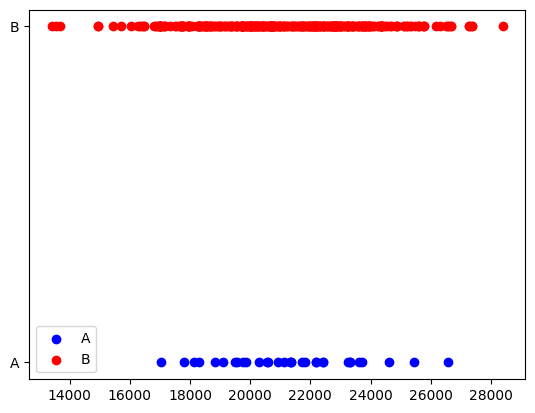

In [16]:
plt.scatter(lr_id, np.zeros_like(lr_id), color='blue', label='A')
plt.scatter(lr_ood, np.ones_like(lr_ood), color='red', label='B')

plt.yticks([0, 1], ['A', 'B'])
plt.legend()
plt.show()

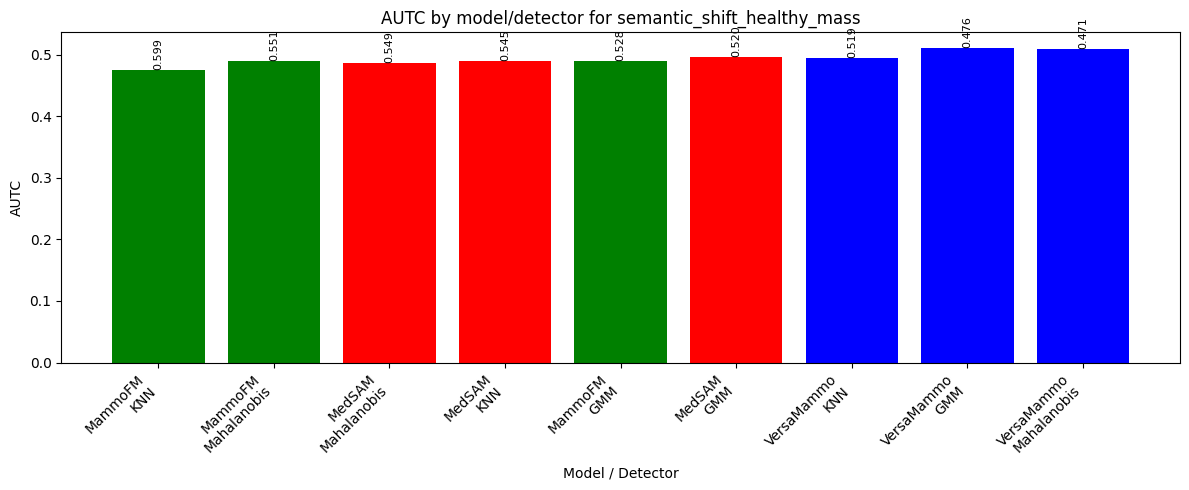

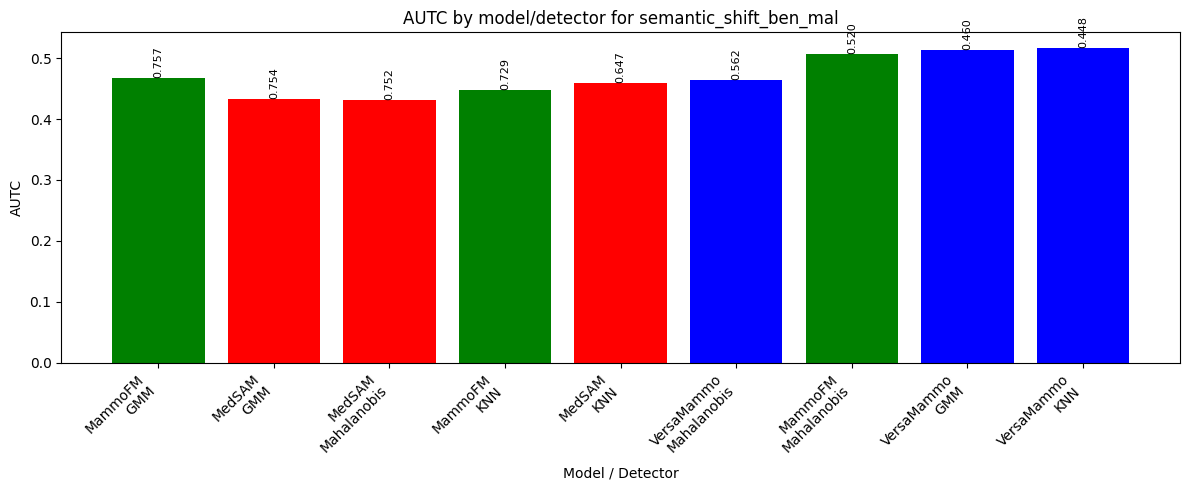

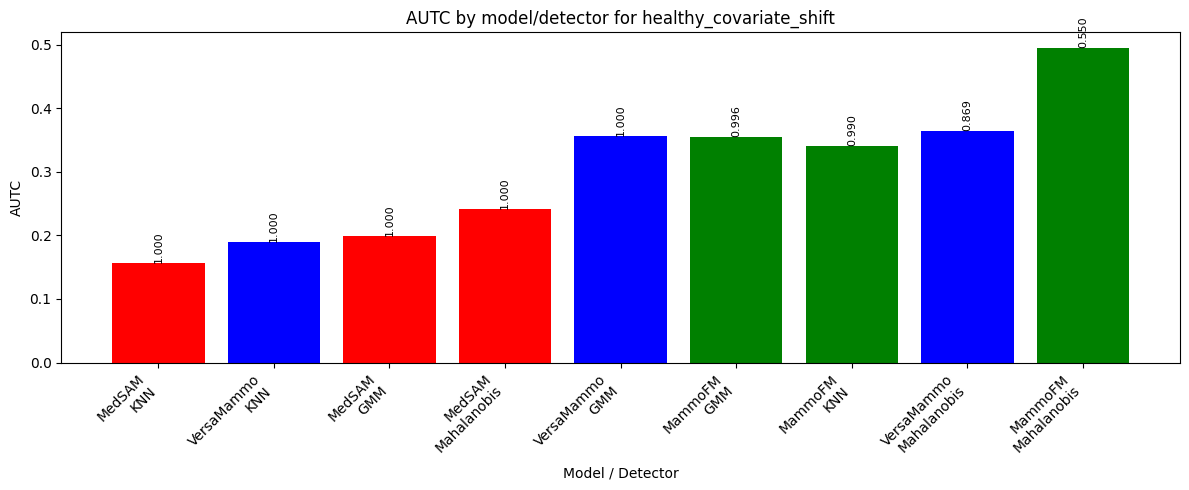

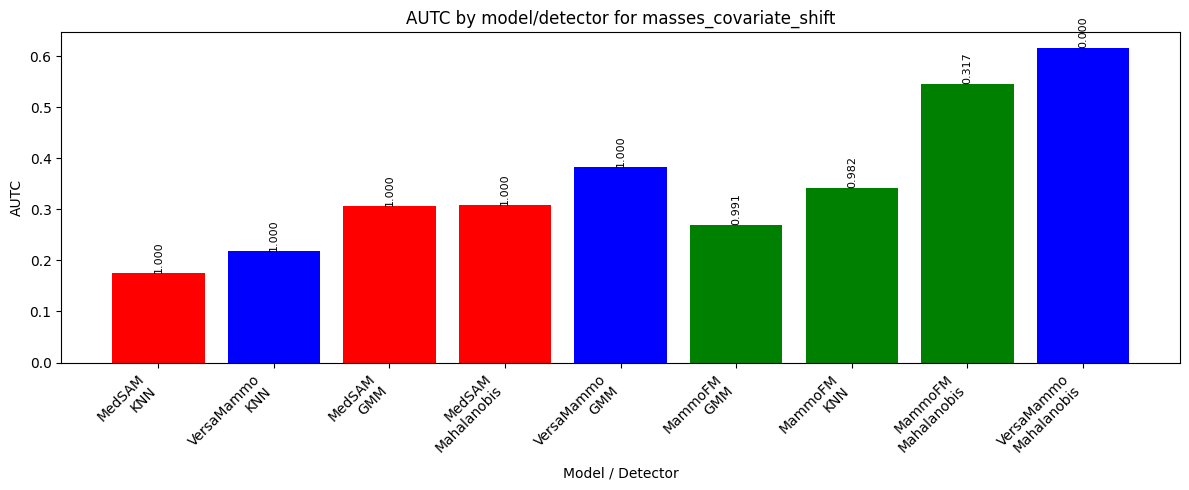

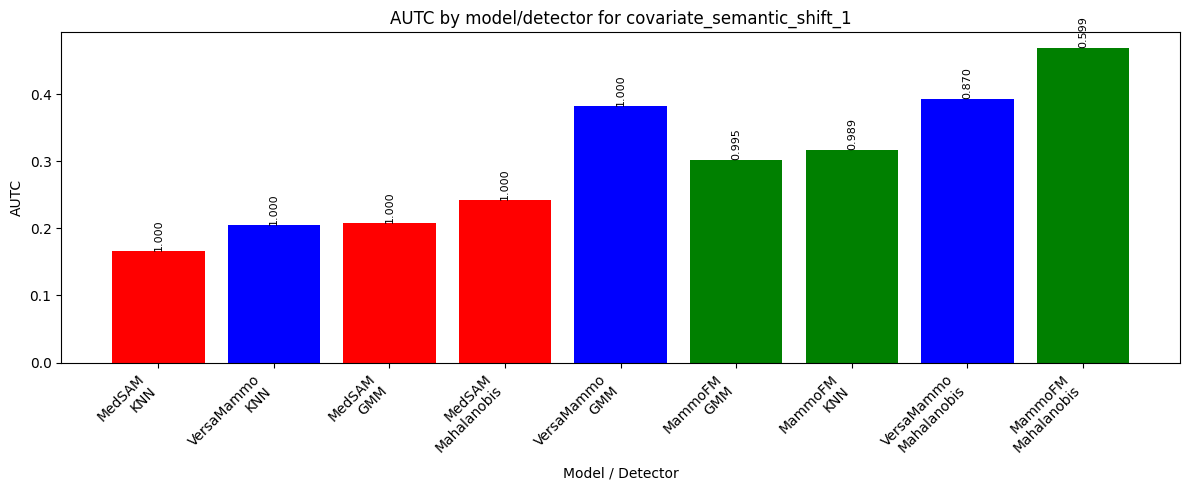

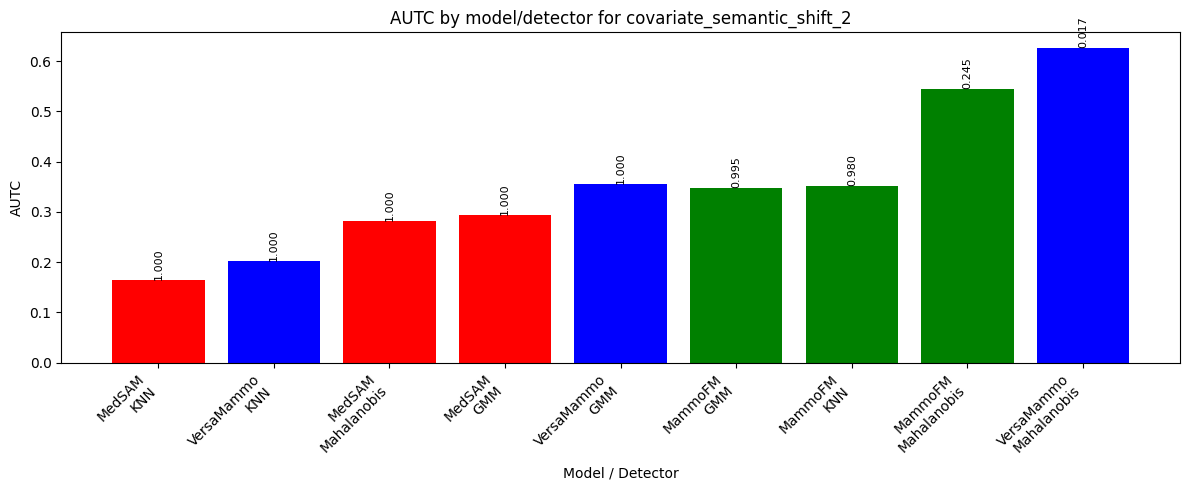

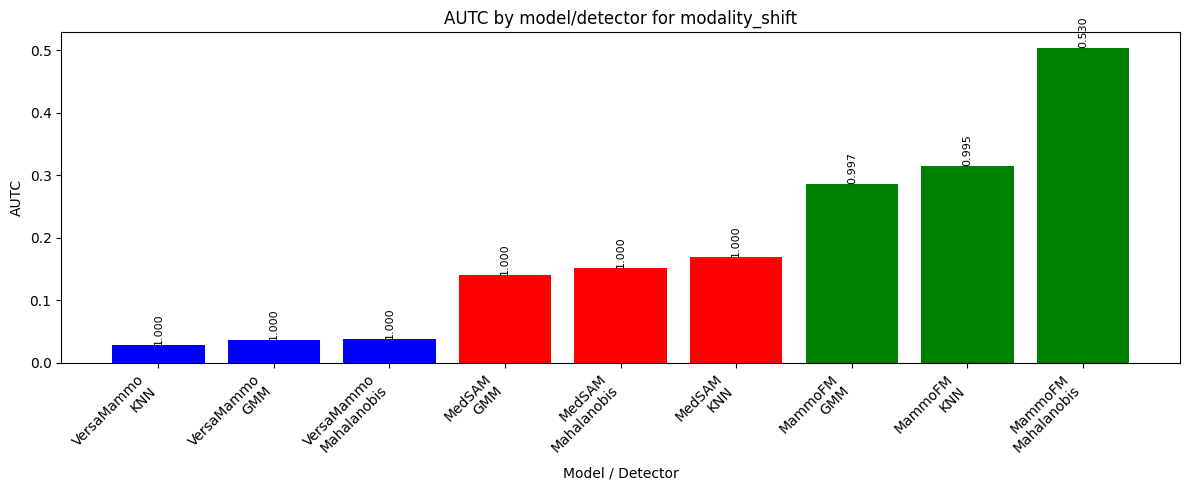

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Flatten nested results dict
rows = []

model_colors = {
    "MedSAM": "red",
    "VersaMammo": "blue",
    "MammoFM": "green",
}

for detector_name, detector_results in results.items():
    for model_name, model_results in detector_results.items():
        for shift_name, metrics in model_results.items():
            rows.append({
                "detector": detector_name,
                "model": model_name,
                "shift": shift_name,
                "AUROC": float(metrics["AUROC"]),
                "AUTC": float(metrics["AUTC"]),
                "FPR95TPR": float(metrics["FPR95TPR"]),
            })

df = pd.DataFrame(rows)


for shift_name in df["shift"].unique():
    d = df[df["shift"] == shift_name].copy()

    d["AUROC_round"] = d["AUROC"].round(3)

    d = d.sort_values(
        by=["AUROC_round", "AUTC"],
        ascending=[False, True]
    )

    labels = d["model"] + "\n" + d["detector"]
    colors = [model_colors[m] for m in d["model"]]

    plt.figure(figsize=(12, 5))
    bars = plt.bar(
        labels,
        d["AUTC"],
        color=colors
    )

    plt.title(f"AUTC by model/detector for {shift_name}")
    plt.ylabel("AUTC")
    plt.xlabel("Model / Detector")
    plt.xticks(rotation=45, ha="right")

    for i, (_, row) in enumerate(d.iterrows()):
        plt.text(
            i,
            row["AUTC"],
            f"{row['AUROC']:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    plt.tight_layout()
    plt.show()

Important caveat

If your actual Mahalanobis score is computed in the original D-dimensional space, then fitting the Gaussian after PCA is only an approximation.

A better projection is:

Fit Gaussian in original feature space.
Sample synthetic points from that Gaussian.
Project both real points and Gaussian samples into PCA or t-SNE.
Plot the samples as the “blob.”


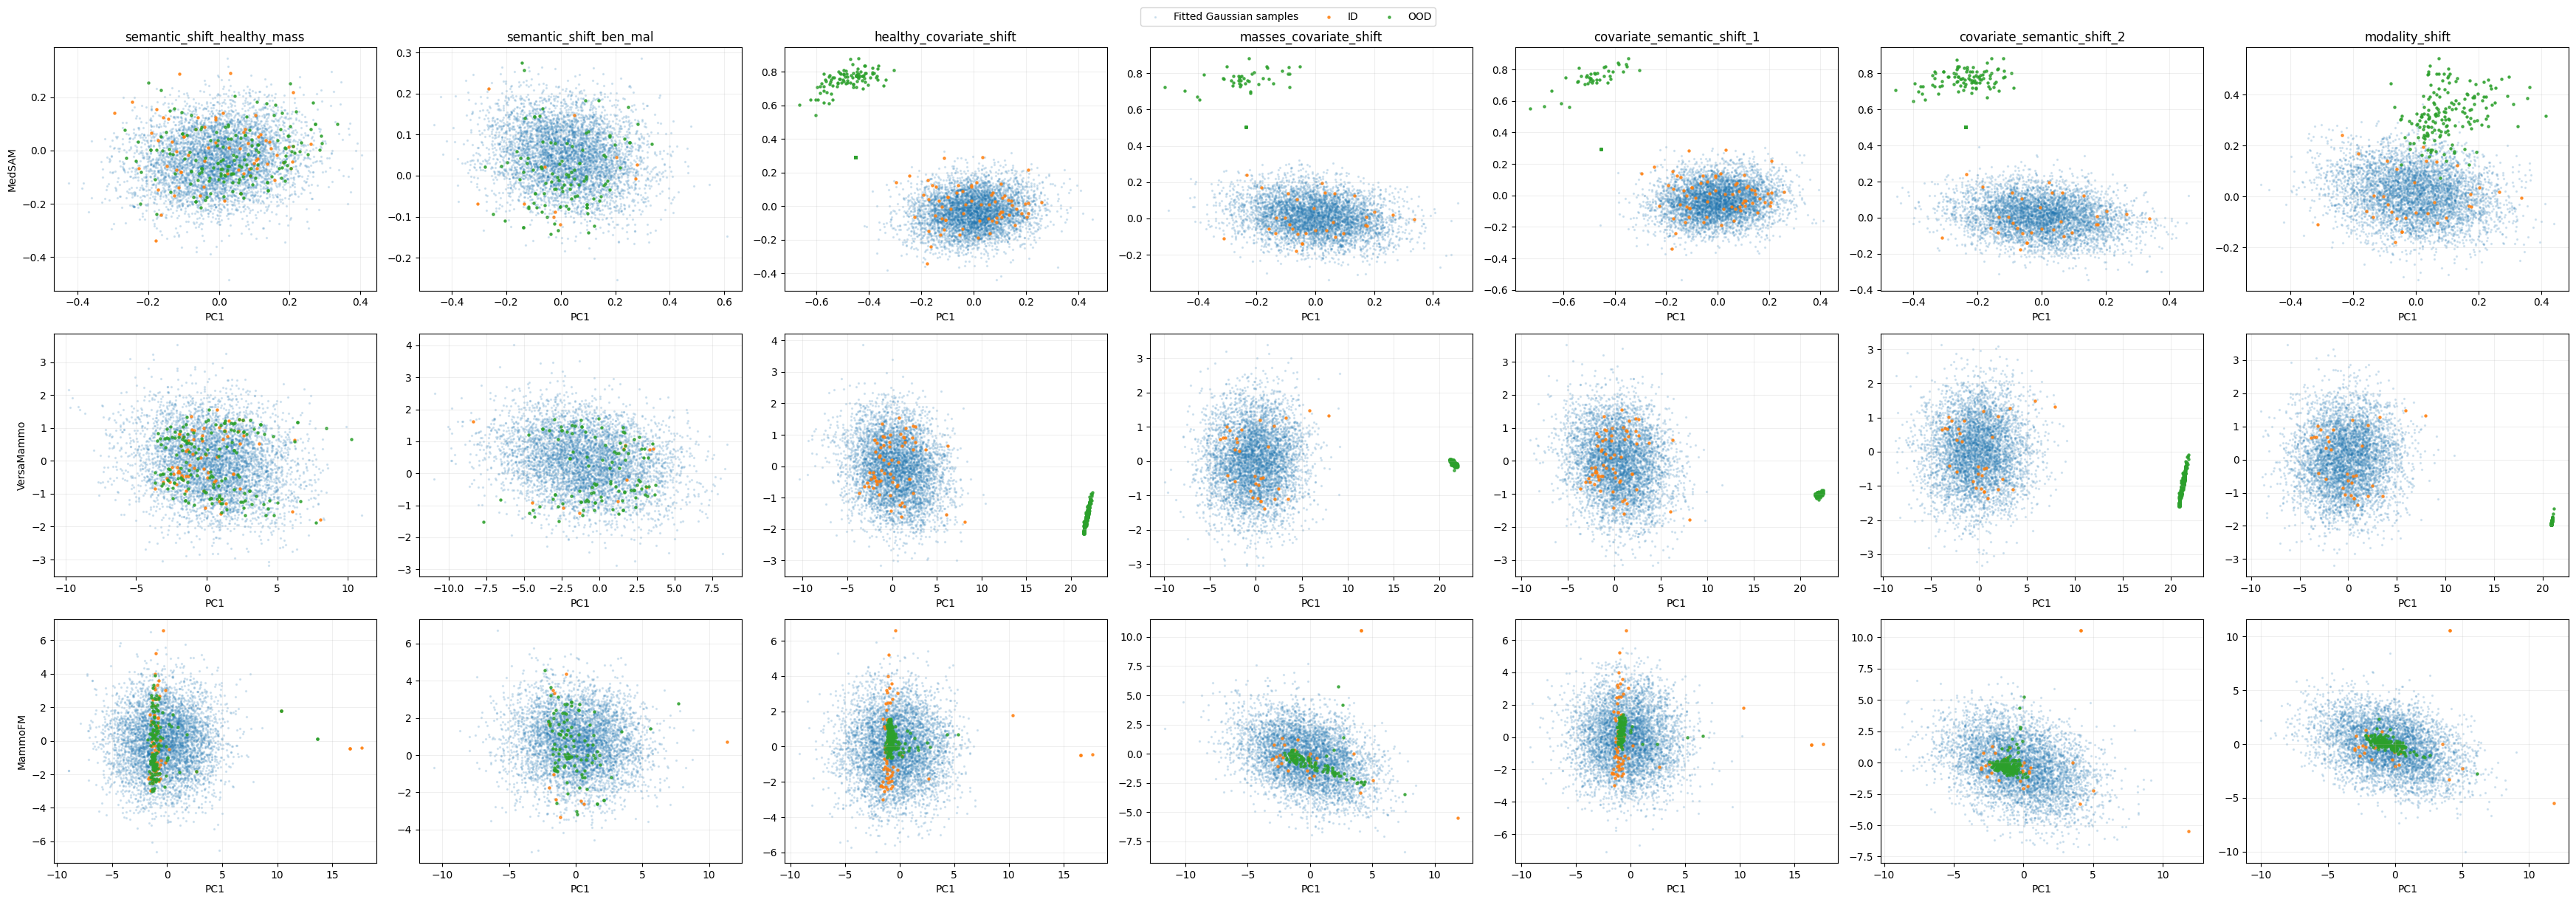

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

shift_combinations_by_model = {}

for model in models:
    zgt_masses = ZGT_dict[model]["masses"]
    zgt_mal_ben = ZGT_dict[model]["mal_ben"]
    inbreast_values = INbreast_dict[model]
    mamamia_values = Mama_mia_dict[model]

    # shift_combinations_by_model[model] = {
    #     "semantic_shift_mass_nomass": zgt_masses,
    #     "semantic_shift_mal_ben": zgt_mal_ben, 
    #     "masses_covariate_shift": [zgt_masses[0], inbreast_values[0]],
    #     "nomasses_covariate_shift": [zgt_masses[1], inbreast_values[1]],
    #     "covariate_semantic_shift_1": [zgt_masses[0], inbreast_values[1]],
    #     "covariate_semantic_shift_2": [zgt_masses[1], inbreast_values[0]],
    #     "modality_shift": [zgt_masses[0], mamamia_values[0]]
    #     }
    
    
    shift_combinations_by_model[model] = {
        "semantic_shift_healthy_mass": zgt_masses,
        "semantic_shift_ben_mal": zgt_mal_ben, 
        "healthy_covariate_shift": [zgt_masses[0], inbreast_values[0]],
        "masses_covariate_shift": [zgt_masses[1], inbreast_values[1]],
        "covariate_semantic_shift_1": [zgt_masses[0], inbreast_values[1]],
        "covariate_semantic_shift_2": [zgt_masses[1], inbreast_values[0]],
        "modality_shift": [zgt_masses[1], mamamia_values[0]]
    }
        
    
models = list(ZGT_dict.keys())
shifts = list(next(iter(shift_combinations_by_model.values())).keys())

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(shifts),
    figsize=(5 * len(shifts), 4 * len(models)),
    squeeze=False
)


for row_idx, model in enumerate(models):
    for col_idx, shift_name in enumerate(shifts):
        ax = axes[row_idx, col_idx]

        v = shift_combinations_by_model[model][shift_name]

        Z_id = torch.load(v[0]).detach().cpu().numpy()
        Z_ood = torch.load(v[1]).detach().cpu().numpy()

        # optional: same 80/20 split as detector fitting
        N_fit = int(Z_id.shape[0] * 0.8)
        Z_id_fit = Z_id[:N_fit]
        Z_id_test = Z_id[N_fit:]

        mu = Z_id_fit.mean(axis=0)
        cov = np.cov(Z_id_fit.T)

        X_gauss = np.random.multivariate_normal(
            mu,
            cov,
            size=5000
        )

        pca = PCA(n_components=2)
        X2_id = pca.fit_transform(Z_id_test)
        X2_ood = pca.transform(Z_ood)
        X2_gauss = pca.transform(X_gauss)

        ax.scatter(
            X2_gauss[:, 0],
            X2_gauss[:, 1],
            s=2,
            alpha=0.15,
            label="Fitted Gaussian samples"
        )
        ax.scatter(
            X2_id[:, 0],
            X2_id[:, 1],
            s=5,
            alpha=0.8,
            label="ID"
        )
        ax.scatter(
            X2_ood[:, 0],
            X2_ood[:, 1],
            s=5,
            alpha=0.8,
            label="OOD"
        )

        if row_idx == 0:
            ax.set_title(shift_name)

        if col_idx == 0:
            ax.set_ylabel(model)

        ax.set_xlabel("PC1")
        ax.grid(alpha=0.2)

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.savefig("projected_gaussians.png", dpi=300, bbox_inches="tight")
plt.show()

This is misleading because it effectively shows separation in only 2 (PCA) dimensions. There is no way of knowing if this separation acutally holds for the entire feature space, where the ID and OOD reside.


Let's have a look at histograms of scores between the two methods: Mahalanobis and KNN and see the kind of separability they achieve:

In [28]:
id_sem_cov=torch.load("./score_plots/MammoFM/id_covariate_semantic_shift_1.pt")
ood_sem_cov=torch.load("./score_plots/MammoFM/ood_covariate_semantic_shift_1.pt")

id_modality=torch.load("./score_plots/MammoFM/id_modality_shift.pt")
ood_modality=torch.load("./score_plots/MammoFM/ood_modality_shift.pt")

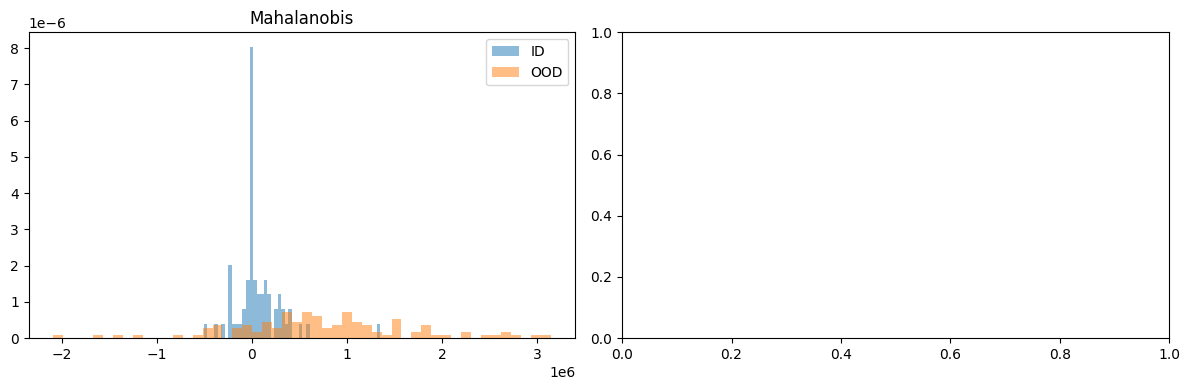

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mahalanobis
axes[0].hist(id_sem_cov, bins=50, density=True, alpha=0.5, label="ID")
axes[0].hist(ood_sem_cov, bins=50, density=True, alpha=0.5, label="OOD")
axes[0].set_title("Mahalanobis")
axes[0].legend()

# # KNN
# axes[1].hist(scores_id_knn, bins=50, density=True, alpha=0.5, label="ID")
# axes[1].hist(scores_ood_knn, bins=50, density=True, alpha=0.5, label="OOD")
# axes[1].set_title("KNN")
# axes[1].legend()

# # KNN
# axes[2].hist(scores_id_gmm, bins=50, density=True, alpha=0.5, label="ID")
# axes[2].hist(scores_ood_gmm, bins=50, density=True, alpha=0.5, label="OOD")
# axes[2].set_title("GMM")
# axes[2].legend()

plt.tight_layout()
plt.show()

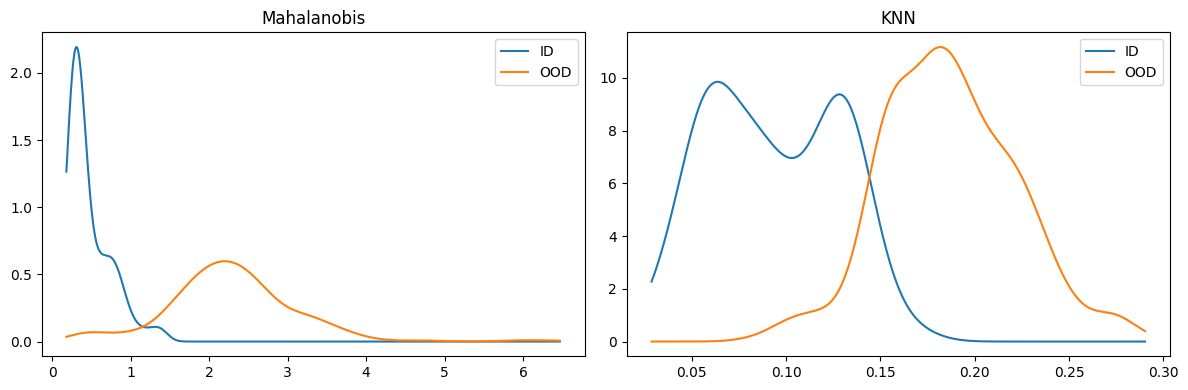

In [108]:
from scipy.stats import gaussian_kde

def plot_kde(ax, id_scores, ood_scores, title):
    x = np.linspace(
        min(id_scores.min(), ood_scores.min()),
        max(id_scores.max(), ood_scores.max()),
        1000
    )

    ax.plot(x, gaussian_kde(id_scores)(x), label="ID")
    ax.plot(x, gaussian_kde(ood_scores)(x), label="OOD")
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_kde(axes[0], scores_id_mds, scores_ood_mds, "Mahalanobis")
plot_kde(axes[1], scores_id_knn, scores_ood_knn, "KNN")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1162/1351945007.py:4: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_id_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:11: RuntimeWarning: invalid value encountered in log10
  np.log10(scores_ood_mds + 1e-8),
/tmp/ipykernel_1162/1351945007.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(scores_ood_mds + 1e-8),


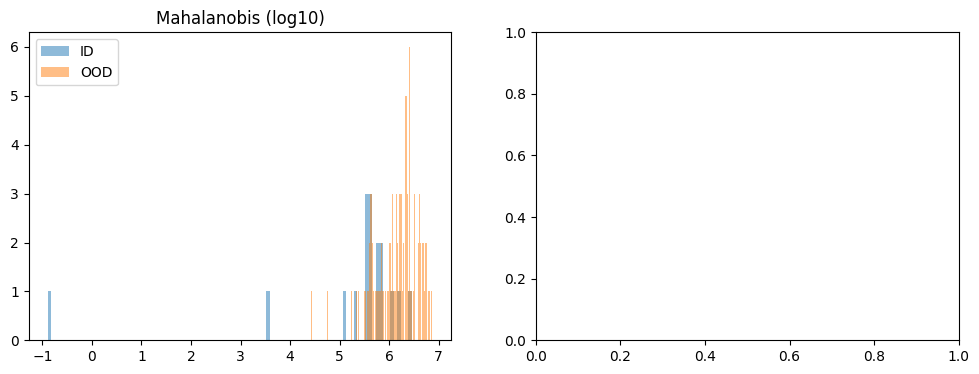

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(
    np.log10(scores_id_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="ID"
)

axes[0].hist(
    np.log10(scores_ood_mds + 1e-8),
    bins=100,
    alpha=0.5,
    label="OOD"
)

axes[0].set_title("Mahalanobis (log10)")
axes[0].legend()

/tmp/ipykernel_329/3203041713.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


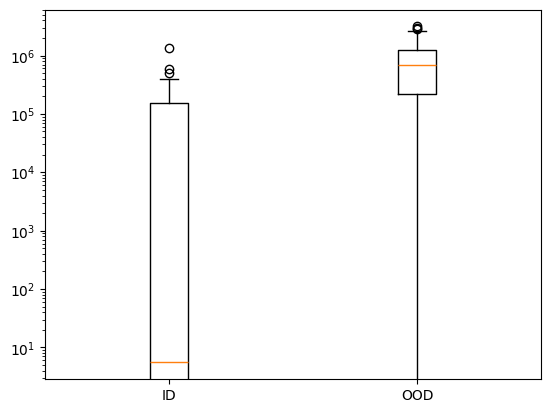

In [30]:
plt.boxplot(
    [id_sem_cov, ood_sem_cov],
    labels=["ID","OOD"]
)
plt.yscale("log")

/tmp/ipykernel_329/3528895006.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


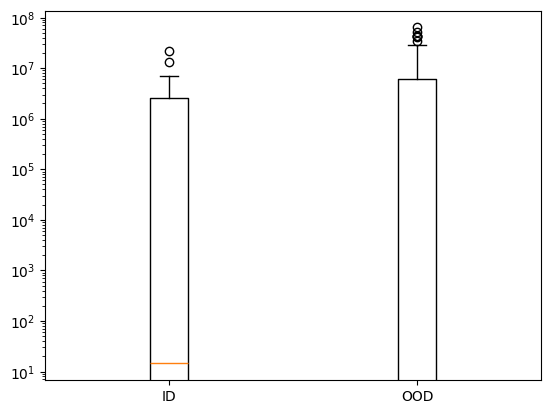

In [31]:
plt.boxplot(
    [id_modality, ood_modality],
    labels=["ID","OOD"]
)
plt.yscale("log")

In [32]:
print(f"scores id percentiles: {np.percentile(id_sem_cov, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(ood_sem_cov, [1,5,25,50,75,95,99])}")

scores id percentiles: [-4.17400292e+05 -2.47884464e+05 -2.86854863e+04  5.51550293e+00
  1.56680133e+05  3.96201103e+05  8.43692374e+05]
scores ood percentiles: [-1576817.85375    -536761.9140625   220863.671875    675759.71875
  1229862.875      2518072.4375     2958283.5425   ]


In [33]:
print(f"scores id percentiles: {np.percentile(id_modality, [1,5,25,50,75,95,99])}")
print(f"scores ood percentiles: {np.percentile(ood_modality, [1,5,25,50,75,95,99])}")

scores id percentiles: [-2.05696542e+07 -6.82638230e+06 -2.21163088e+06  1.44190187e+01
  2.54586625e+06  9.83477760e+06  1.91823954e+07]
scores ood percentiles: [-85453272.        -62649174.        -10148646.         -1497607.375
   6193314.         27799625.         46255464.0000001]


In [36]:
auroc_sem_cov=auroc_torchmetrics_from_distances(id_sem_cov,ood_sem_cov, higher_is_ood=True)
auroc_modality=auroc_torchmetrics_from_distances(id_modality,ood_modality, higher_is_ood=True)

In [38]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(id_sem_cov), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(ood_sem_cov), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([id_sem_cov.detach().cpu(), ood_sem_cov.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.6417911052703857, 'AUTC': 0.43395063281059265, 'AUPR-IN': 0.5925832986831665, 'AUPR-OUT': 0.8212032318115234, 'FPR95TPR': 1.0}


In [24]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(id_modality), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(ood_modality), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([id_modality.detach().cpu(), ood_modality.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.109375, 'AUTC': 0.9628419876098633, 'AUPR-IN': 0.19192340970039368, 'AUPR-OUT': 0.4211822748184204, 'FPR95TPR': 1.0}


In [37]:
print(auroc_sem_cov)

0.7914594411849976
